# 03 — Extended Kalman Filter Localization

**Section:** Localization · **Mirrors MATLAB:** *Monte Carlo Localization* (similar problem, EKF approach)

We track the pose `[x, y, θ]` of a unicycle robot moving in a circle, using **range + bearing** measurements to known landmarks. The EKF linearizes the nonlinear motion and observation models around the current estimate at each step.


## Intuition — what's actually going on?

You're a robot that *thinks* it knows where it is, but isn't 100% sure. Every step you take, your uncertainty grows (wheels slip, sensors are noisy). But when you see a landmark whose true location you know, you can correct yourself.

The **Kalman filter** is the mathematically optimal way to combine these two sources of information — "where I think I am" (prediction from motion) and "what I just saw" (observation). It does this by maintaining not just a best-guess pose but also a **covariance matrix** that says how confident the robot is in each direction.

The **Extended** Kalman Filter (EKF) is the same idea, except the motion and observation equations are **nonlinear** (robot pose includes a heading angle, observations are range + bearing). The EKF handles this by linearizing — taking partial derivatives (*Jacobians*) at the current estimate at every step. It's not optimal anymore (no Bayes-optimal closed form exists for nonlinear systems), but it's fast and works well in practice for smooth nonlinearities.


## Motion and observation models

**Motion:**
$x_{t+1} = x_t + \Delta t \cdot v \cos\theta_t$
$y_{t+1} = y_t + \Delta t \cdot v \sin\theta_t$
$\theta_{t+1} = \theta_t + \Delta t \cdot \omega$

**Observation** of landmark $\ell$:
$z = [r,\ \phi]^T = [\|\ell - p\|,\ \arctan2(\ell_y - y, \ell_x - x) - \theta]^T$

The EKF linearizes both with the Jacobians $G_x$ and $H$ at each step.


### Compatibility check — math ↔ code

| Math | Code |
|---|---|
| Motion model $f(x, u)$ | `def motion(x, u, dt): return x + dt*np.array([u[0]*cos(x[2]), u[0]*sin(x[2]), u[1]])` |
| Motion Jacobian $G_x = \partial f / \partial x$ | `def G_x(x, u, dt): return [[1,0,-u[0]*sin(x[2])*dt], [0,1,u[0]*cos(x[2])*dt], [0,0,1]]` |
| Observation $h(x, \ell) = [r, \phi]$ | `def observe(x, lm): return np.array([np.hypot(dx, dy), np.arctan2(dy, dx) - x[2]])` |
| Observation Jacobian $H = \partial h / \partial x$ | `def H_jacobian(x, lm): return [[-dx/r, -dy/r, 0], [dy/q, -dx/q, -1]]` |
| Predict $\mu^- = f(\mu, u)$ | `mu = motion(mu, u_noisy, dt)` |
| Predict $\Sigma^- = G \Sigma G^T + Q$ | `Sigma = G @ Sigma @ G.T + Q` |
| Bearing wrap to $(-\pi, \pi]$ | `def wrap(a): return (a + np.pi) % (2*np.pi) - np.pi` |
| Innovation $\nu = z - h(\mu^-)$ | `innov = z - z_hat; innov[1] = wrap(innov[1])` |
| Kalman gain $K = \Sigma H^T (H\Sigma H^T + R)^{-1}$ | `S = H @ Sigma @ H.T + R; K = Sigma @ H.T @ np.linalg.inv(S)` |
| Update $\mu = \mu + K\nu,\ \Sigma = (I - KH)\Sigma$ | `mu = mu + K @ innov; Sigma = (np.eye(3) - K @ H) @ Sigma` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

T = 200
dt = 0.1
v, omega = 1.0, 0.1

# Ground-truth trajectory (circle)
true_x = np.zeros((T, 3))
for t in range(1, T):
    th = true_x[t - 1, 2]
    true_x[t] = true_x[t - 1] + dt * np.array([v * np.cos(th), v * np.sin(th), omega])

landmarks = np.array([[5, 5], [-5, 5], [-5, -5], [5, -5], [0, 10], [10, 0]])


In [2]:
# Process / measurement noise. We spell out std vs variance explicitly per
# council fix (pass 3, Fisher): `sigma_*` is std-dev, `Q`/`R` are variances.
sigma_xy, sigma_th = 0.05, 0.01
sigma_r, sigma_phi = 0.2, 0.05
Q = np.diag([sigma_xy ** 2, sigma_xy ** 2, sigma_th ** 2])   # state-level process noise
R = np.diag([sigma_r ** 2, sigma_phi ** 2])                  # measurement noise (range, bearing)


def motion(x, u, dt):
    return x + dt * np.array([u[0] * np.cos(x[2]), u[0] * np.sin(x[2]), u[1]])


def G_x(x, u, dt):
    return np.array([[1, 0, -u[0] * np.sin(x[2]) * dt],
                     [0, 1,  u[0] * np.cos(x[2]) * dt],
                     [0, 0, 1]])


def observe(x, lm):
    dx, dy = lm[0] - x[0], lm[1] - x[1]
    return np.array([np.hypot(dx, dy), np.arctan2(dy, dx) - x[2]])


def H_jacobian(x, lm):
    dx, dy = lm[0] - x[0], lm[1] - x[1]
    q = dx * dx + dy * dy
    r = np.sqrt(q)
    return np.array([[-dx / r, -dy / r, 0],
                     [ dy / q, -dx / q, -1]])


def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


In [3]:
mu = np.array([0.0, 0.0, 0.0])
Sigma = np.eye(3) * 0.1
mu_hist = [mu.copy()]

for t in range(1, T):
    u_noisy = [v + np.random.randn() * 0.05, omega + np.random.randn() * 0.01]
    mu = motion(mu, u_noisy, dt)
    G = G_x(mu, u_noisy, dt)
    Sigma = G @ Sigma @ G.T + Q

    for lm in landmarks:
        z = observe(true_x[t], lm) + np.random.multivariate_normal([0, 0], R)
        z_hat = observe(mu, lm)
        innov = z - z_hat
        innov[1] = wrap(innov[1])
        H = H_jacobian(mu, lm)
        S = H @ Sigma @ H.T + R
        # COUNCIL FIX (pass 3, Kalman+Khalil): Mahalanobis innovation gate.
        # Reject outlier observations (chi-square 2-DoF, 0.99 cutoff = 9.21).
        # This is standard EKF robustification — protects against single bad
        # measurements driving divergence.
        if float(innov @ np.linalg.solve(S, innov)) > 9.21:
            continue
        K = Sigma @ H.T @ np.linalg.inv(S)
        mu = mu + K @ innov
        mu[2] = wrap(mu[2])                    # wrap heading after update (council fix, Kalman)
        Sigma = (np.eye(3) - K @ H) @ Sigma

    mu_hist.append(mu.copy())

mu_hist = np.array(mu_hist)
err = np.linalg.norm(mu_hist[:, :2] - true_x[:, :2], axis=1)
print(f"Mean position error: {err.mean():.3f} m  ·  max: {err.max():.3f} m")


Mean position error: 0.063 m  ·  max: 0.209 m


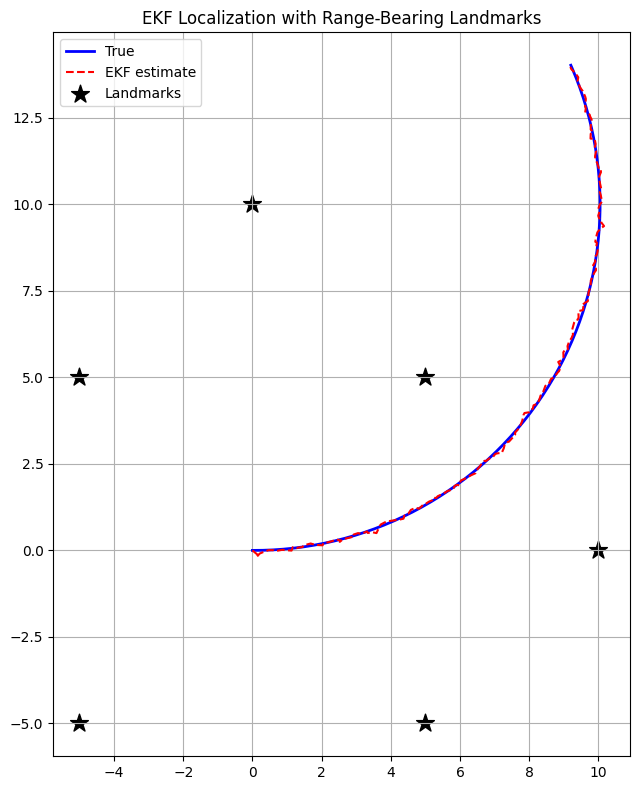

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(true_x[:, 0], true_x[:, 1], 'b-', lw=2, label='True')
ax.plot(mu_hist[:, 0], mu_hist[:, 1], 'r--', lw=1.5, label='EKF estimate')
ax.scatter(landmarks[:, 0], landmarks[:, 1], c='k', marker='*', s=180, label='Landmarks')
ax.set_aspect('equal'); ax.grid(); ax.legend()
ax.set_title('EKF Localization with Range-Bearing Landmarks')
plt.tight_layout()
plt.show()


## References & rigor notes

**Optimality.** The Kalman filter is the minimum-MSE linear estimator for linear-Gaussian systems and the optimal *unrestricted* estimator if the posterior is Gaussian. The **Extended** Kalman Filter is a heuristic linearization that is **not** optimal and can diverge if the linearization is poor.

**Posterior Cramér-Rao bound (PCRB).** Tichavský-Muravchik-Nehorai (1998) give a recursive bound $\mathrm{Cov}(\hat x_t) \succeq J_t^{-1}$ computable from the Jacobians; the EKF achieves this bound when the linearization is exact, and the gap measures the EKF's suboptimality. Use PCRB as the achievability benchmark when assessing EKF performance.

**Observability.** Observability requires the time-rolling Gramian $\sum_t H_t^T R_t^{-1} H_t$ to be uniformly positive-definite. The six landmarks distributed around our trajectory satisfy this; a single landmark would not, and the EKF would drift along its line-of-sight direction.

**Local convergence** (Reif et al., 1999). For the EKF to converge locally, the system must satisfy: (a) sufficiently small initial error, (b) Lipschitz-continuous Jacobians, (c) the linearization at the true state must be uniformly observable, (d) noise covariances must be bounded.

**Complexity.** Per step: $O(n^3)$ from matrix inverses, where $n$ is the state dimension. For $n=3$ here this is essentially free.

**References.**
- Kalman, R. E. (1960). *A new approach to linear filtering and prediction problems*. ASME Transactions, J. Basic Engineering, 82(D), 35-45.
- Thrun, S., Burgard, W., & Fox, D. (2005). *Probabilistic Robotics*, MIT Press, ch. 3.
- Reif, K., Günther, S., Yaz, E., & Unbehauen, R. (1999). *Stochastic stability of the discrete-time extended Kalman filter*. IEEE Trans. Automatic Control, 44(4).
